<a href="https://colab.research.google.com/github/JustDataSimple/CustomerComplaintAnalysis/blob/main/CustomerPersonalityAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')
print(f"Shape of the dataset: {df.shape}")
display(df.head())

Shape of the dataset: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Income    24
dtype: int64


In [ ]:
print('\nColumns with a single unique value:')
single_value_cols = [col for col in df.columns if df[col].nunique() == 1]
if single_value_cols:
    for col in single_value_cols:
        print(f"- {col}: {df[col].iloc[0]}")
else:
    print("No columns with a single unique value.")


Columns with a single unique value:
- Z_CostContact: 3
- Z_Revenue: 11


In [ ]:
print('\nDescription of Income column:')
print(df['Income'].describe())


Description of Income column:
count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64


In [ ]:
print('\nConverting Dt_Customer to datetime...')
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
print(df['Dt_Customer'].head())


Converting Dt_Customer to datetime...
0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]


In [ ]:
print('\nValues for Z_CostContact:')
print(df['Z_CostContact'].value_counts())


Values for Z_CostContact:
Z_CostContact
3    2240
Name: count, dtype: int64


In [ ]:
print('\nValues for Z_Revenue:')
print(df['Z_Revenue'].value_counts())


Values for Z_Revenue:
Z_Revenue
11    2240
Name: count, dtype: int64


In [ ]:
print('\nChecking for outliers in Year_Birth:')
print(df['Year_Birth'].value_counts().sort_index())
print(df['Year_Birth'].describe())


Checking for outliers in Year_Birth:
Year_Birth
1893     1
1899     1
1900     1
1940     1
1941     1
1943     6
1944     7
1945     8
1946    16
1947    16
1948    21
1949    30
1950    29
1951    42
1952    52
1953    35
1954    49
1955    48
1956    55
1957    41
1958    52
1959    50
1960    49
1961    35
1962    44
1963    44
1964    41
1965    74
1966    50
1967    44
1968    51
1969    70
1970    75
1971    86
1972    78
1973    72
1974    69
1975    83
1976    89
1977    52
1978    76
1979    53
1980    39
1981    38
1982    44
1983    41
1984    38
1985    32
1986    41
1987    27
1988    29
1989    29
1990    18
1991    15
1992    13
1993     5
1994     3
1995     5
1996     2
Name: count, dtype: int64
count    2216.000000
mean     1968.820397
std        11.985554
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64


In [ ]:
print('\nRemoving extreme outliers from Year_Birth (born before 1940)...')
df = df[df['Year_Birth'] > 1940]

print(f"New shape of the dataset after removing Year_Birth outliers: {df.shape}")
print('\nUpdated Year_Birth distribution:')
print(df['Year_Birth'].value_counts().sort_index())
print(df['Year_Birth'].describe())


Removing extreme outliers from Year_Birth (born before 1940)...
New shape of the dataset after removing Year_Birth outliers: (2212, 27)

Updated Year_Birth distribution:
Year_Birth
1941     1
1943     6
1944     7
1945     8
1946    16
1947    16
1948    21
1949    30
1950    29
1951    42
1952    52
1953    35
1954    49
1955    48
1956    55
1957    41
1958    52
1959    50
1960    49
1961    35
1962    44
1963    44
1964    41
1965    74
1966    50
1967    44
1968    51
1969    70
1970    75
1971    86
1972    78
1973    72
1974    69
1975    83
1976    89
1977    52
1978    76
1979    53
1980    39
1981    38
1982    44
1983    41
1984    38
1985    32
1986    41
1987    27
1988    29
1989    29
1990    18
1991    15
1992    13
1993     5
1994     3
1995     5
1996     2
Name: count, dtype: int64
count    2212.000000
mean     1968.930380
std        11.686685
min      1941.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, d

In [ ]:
import datetime

# Age
now = datetime.datetime.now()
df['Age'] = now.year - df['Year_Birth']

# EnrollmentAge (assuming the analysis date is around the latest Dt_Customer date in the dataset)
latest_customer_date = df['Dt_Customer'].max()
df['EnrollmentAge'] = (latest_customer_date - df['Dt_Customer']).dt.days

# FamilySize and Is_Parent
df['FamilySize'] = df['Kidhome'] + df['Teenhome'] + 1 # +1 for the customer itself
df['Is_Parent'] = df['Kidhome'] + df['Teenhome']
df['Is_Parent'] = df['Is_Parent'].apply(lambda x: 1 if x > 0 else 0)

# TotalMnt (total amount spent)
df['TotalMnt'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                 df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# TotalPurchases
df['TotalPurchases'] = df['NumDealsPurchases'] + df['NumWebPurchases'] + \
                       df['NumCatalogPurchases'] + df['NumStorePurchases']

# AcceptedCmpOverall
df['AcceptedCmpOverall'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + \
                           df['AcceptedCmp3'] + df['AcceptedCmp4'] + \
                           df['AcceptedCmp5'] + df['Response']

print("New features created successfully!")
display(df[['Age', 'EnrollmentAge', 'FamilySize', 'Is_Parent', 'TotalMnt', 'TotalPurchases', 'AcceptedCmpOverall']].head())

In [ ]:
print('Dropping Z_CostContact and Z_Revenue columns...')
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])
print('Dropping rows with missing Income values...')
df = df.dropna(subset=['Income'])

print(f"New shape of the dataset: {df.shape}")
print('\nChecking for remaining missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Dropping Z_CostContact and Z_Revenue columns...
Dropping rows with missing Income values...
New shape of the dataset: (2216, 27)

Checking for remaining missing values:
Series([], dtype: int64)


# Task
The user wants to perform an exploratory data analysis on the provided marketing campaign dataset. The analysis plan involves: describing engineered features, visualizing age and income distributions, analyzing total spending by education level, total purchases by marital status, and generating a correlation heatmap. Finally, a summary of key insights and next steps is required.

## Describe Engineered Features

### Subtask:
Provide descriptive statistics for the newly created features such as Age, EnrollmentAge, FamilySize, Is_Parent, TotalMnt, TotalPurchases, and AcceptedCmpOverall to understand their distributions.


**Reasoning**:
Generate descriptive statistics for the engineered features to understand their distributions as per the instructions.



**Reasoning**:
Re-creating the engineered features to ensure they are present in the current DataFrame, and then displaying their descriptive statistics as requested by the subtask.



In [ ]:
import datetime

# Age
now = datetime.datetime.now()
df['Age'] = now.year - df['Year_Birth']

# EnrollmentAge (assuming the analysis date is around the latest Dt_Customer date in the dataset)
latest_customer_date = df['Dt_Customer'].max()
df['EnrollmentAge'] = (latest_customer_date - df['Dt_Customer']).dt.days

# FamilySize and Is_Parent
df['FamilySize'] = df['Kidhome'] + df['Teenhome'] + 1 # +1 for the customer itself
df['Is_Parent'] = df['Kidhome'] + df['Teenhome']
df['Is_Parent'] = df['Is_Parent'].apply(lambda x: 1 if x > 0 else 0)

# TotalMnt (total amount spent)
df['TotalMnt'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                 df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# TotalPurchases
df['TotalPurchases'] = df['NumDealsPurchases'] + df['NumWebPurchases'] + \
                       df['NumCatalogPurchases'] + df['NumStorePurchases']

# AcceptedCmpOverall
df['AcceptedCmpOverall'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + \
                           df['AcceptedCmp3'] + df['AcceptedCmp4'] + \
                           df['AcceptedCmp5'] + df['Response']

engineered_features = ['Age', 'EnrollmentAge', 'FamilySize', 'Is_Parent', 'TotalMnt', 'TotalPurchases', 'AcceptedCmpOverall']
print(df[engineered_features].describe())

               Age  EnrollmentAge   FamilySize    Is_Parent     TotalMnt  \
count  2212.000000    2212.000000  2212.000000  2212.000000  2212.000000   
mean     57.069620     353.730561     1.948011     0.714738   607.225136   
std      11.686685     202.496516     0.749196     0.451641   602.548859   
min      30.000000       0.000000     1.000000     0.000000     5.000000   
25%      49.000000     180.000000     1.000000     0.000000    69.000000   
50%      56.000000     356.000000     2.000000     1.000000   397.000000   
75%      67.000000     529.000000     2.000000     1.000000  1048.000000   
max      85.000000     699.000000     4.000000     1.000000  2525.000000   

       TotalPurchases  AcceptedCmpOverall  
count     2212.000000         2212.000000  
mean        14.892405            0.448915  
std          7.671052            0.893017  
min          0.000000            0.000000  
25%          8.000000            0.000000  
50%         15.000000            0.000000  
75%    

## Visualize Age Distribution

### Subtask:
Generate a histogram or density plot to visualize the distribution of customer ages to identify primary age groups.


**Reasoning**:
The subtask is to visualize the distribution of customer ages. I will use `seaborn.histplot` to create a histogram and KDE plot, along with `matplotlib.pyplot` for customization, as per the instructions.



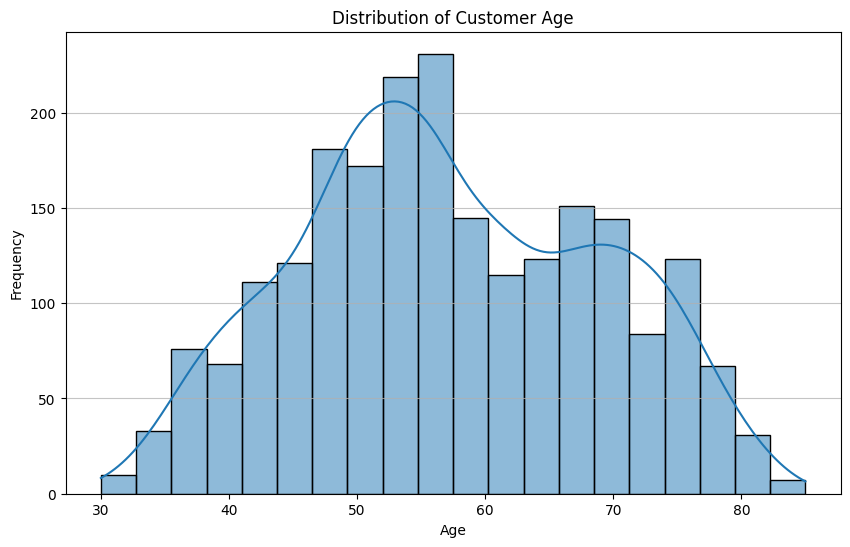

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Visualize Income Distribution

### Subtask:
Generate a histogram or density plot to visualize the distribution of customer incomes, helping to understand the wealth segments within our customer base. Include appropriate labels and a title.


**Reasoning**:
The subtask requires generating a histogram or density plot for customer income. This step will use `seaborn` to create a histogram with KDE and `matplotlib` to add a title, labels, and display the plot.



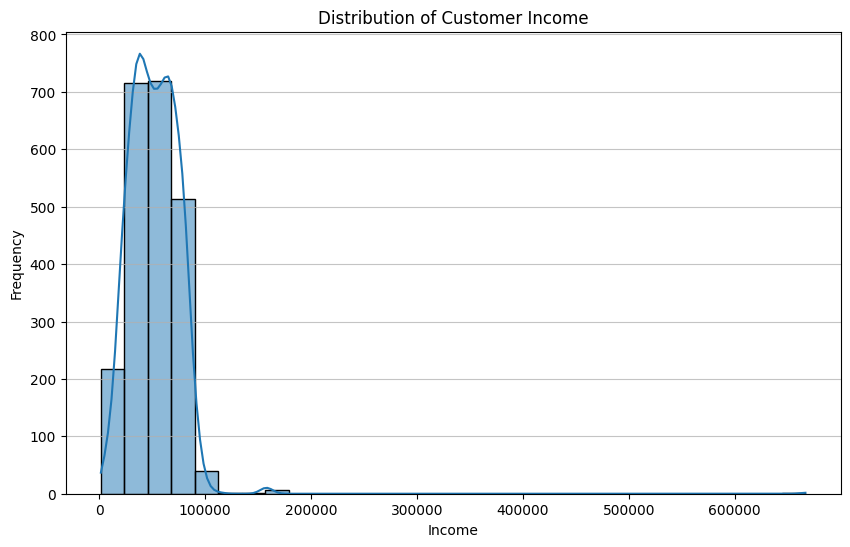

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], kde=True, bins=30) # Using 30 bins for better resolution
plt.title('Distribution of Customer Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Total Spending by Education Level

### Subtask:
Create a bar chart showing the average 'TotalMnt' (total amount spent) across different 'Education' levels to identify potential spending patterns related to education.


**Reasoning**:
To visualize the total spending by education level, I need to group the DataFrame by 'Education' and calculate the mean of 'TotalMnt' for each group. Then, I will create a bar plot using `seaborn` and `matplotlib`.



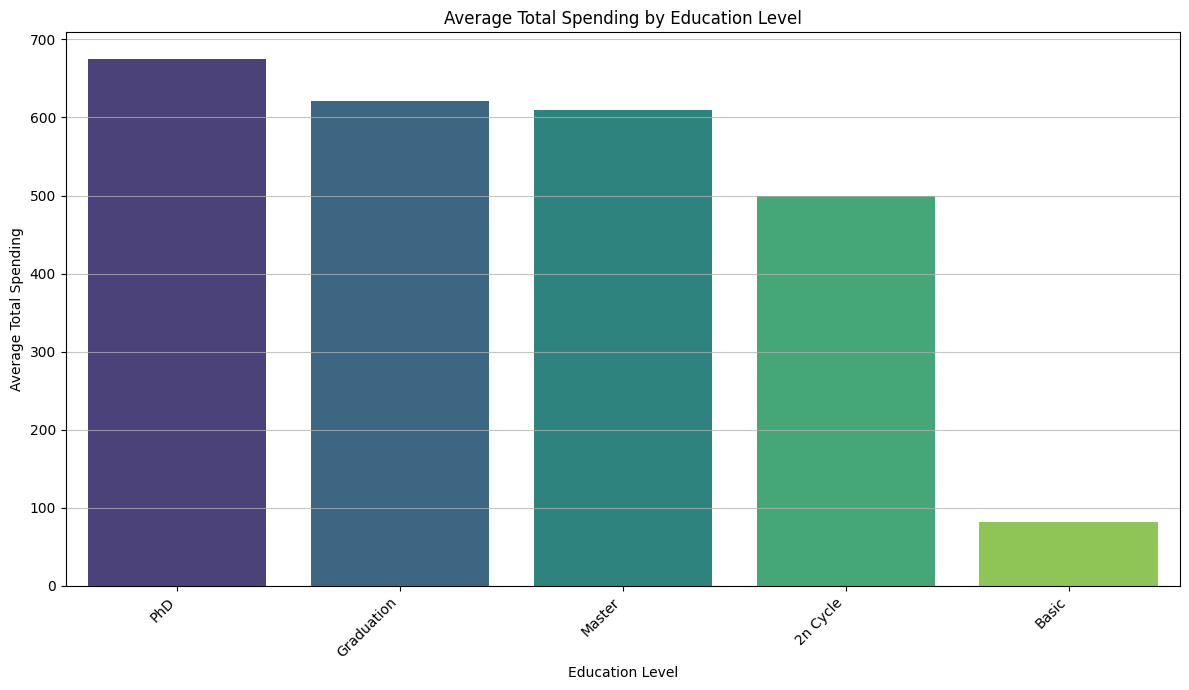

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_spending_by_education = df.groupby('Education')['TotalMnt'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_spending_by_education.index, y=avg_spending_by_education.values, hue=avg_spending_by_education.index, palette='viridis', legend=False)
plt.title('Average Total Spending by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Total Spending')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Total Purchases by Marital Status

### Subtask:
Generate a bar chart illustrating the average 'TotalPurchases' for each 'Marital_Status' category to explore how marital status might influence purchasing frequency.


**Reasoning**:
The subtask requires visualizing the average 'TotalPurchases' by 'Marital_Status'. I will group the DataFrame by 'Marital_Status', calculate the mean of 'TotalPurchases', and then use seaborn to create a bar plot with appropriate labels and title.



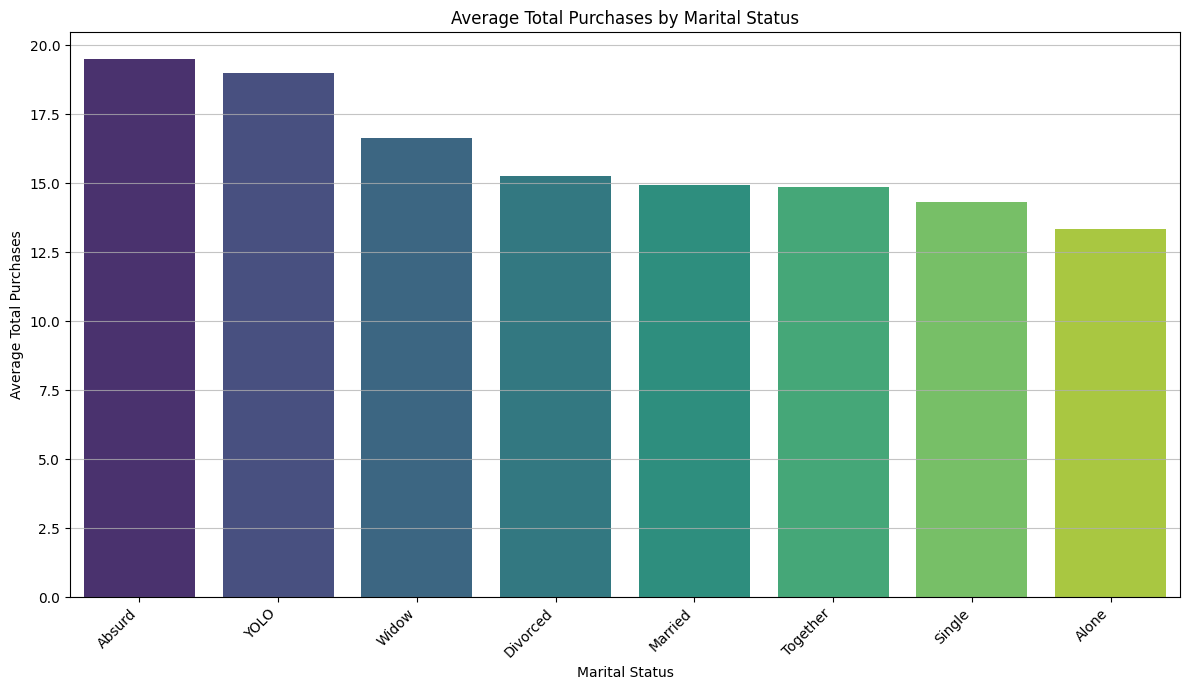

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_purchases_by_marital_status = df.groupby('Marital_Status')['TotalPurchases'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_purchases_by_marital_status.index, y=avg_purchases_by_marital_status.values, hue=avg_purchases_by_marital_status.index, palette='viridis', legend=False)
plt.title('Average Total Purchases by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Average Total Purchases')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Correlation Heatmap

### Subtask:
Generate a correlation heatmap of key numerical features, including the engineered features and original spending columns, to identify strong relationships and dependencies between variables. Ensure the heatmap is clearly labeled.


**Reasoning**:
The subtask requires generating a correlation heatmap. I will first define the list of relevant numerical features, then compute the correlation matrix, and finally use `seaborn.heatmap` to visualize it with annotations and a 'coolwarm' colormap.



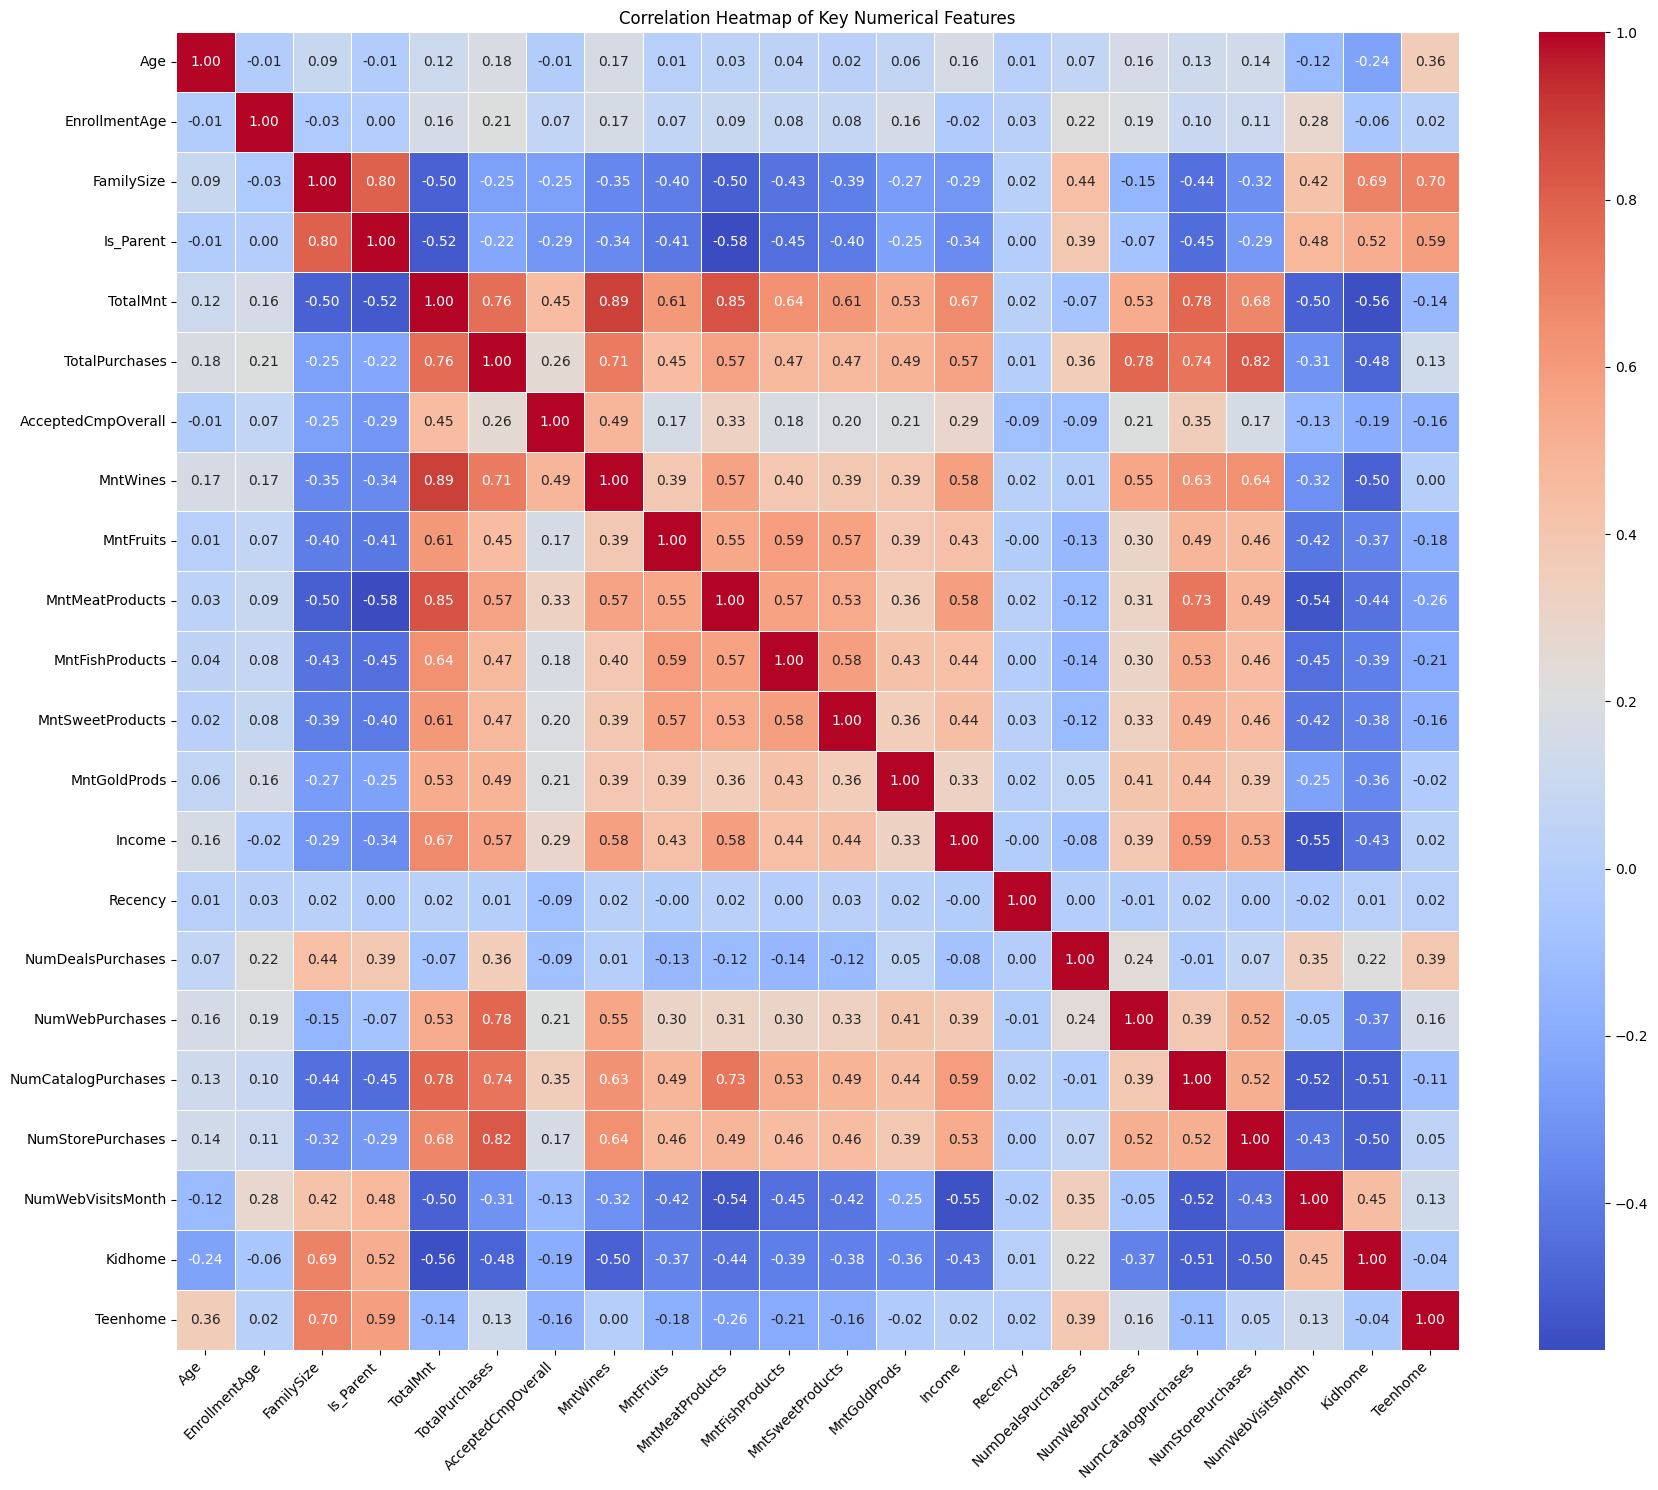

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the relevant numerical columns
numerical_features = [
    'Age', 'EnrollmentAge', 'FamilySize', 'Is_Parent', 'TotalMnt', 'TotalPurchases', 'AcceptedCmpOverall',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Kidhome', 'Teenhome'
]

# Calculate the correlation matrix
correlation_matrix = df[numerical_features].corr()

# Create the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key insights gained from the exploratory data analysis and visualizations, and discuss potential next steps for further analysis or product modifications based on customer behavior, needs, and concerns.


# Task
Perform an exploratory data analysis on the provided marketing campaign dataset. This involves: describing engineered features, visualizing age and income distributions, analyzing total spending by education level, total purchases by marital status, generating a correlation heatmap, visualizing EnrollmentAge, FamilySize, and Is_Parent distributions, and finally summarizing key insights and next steps.

## Visualize EnrollmentAge Distribution

### Subtask:
Generate a histogram or density plot to visualize the distribution of `EnrollmentAge` to understand how long customers have been enrolled.


**Reasoning**:
Generate a histogram with KDE for 'EnrollmentAge' using seaborn to visualize its distribution, and add proper labels and title for clarity.



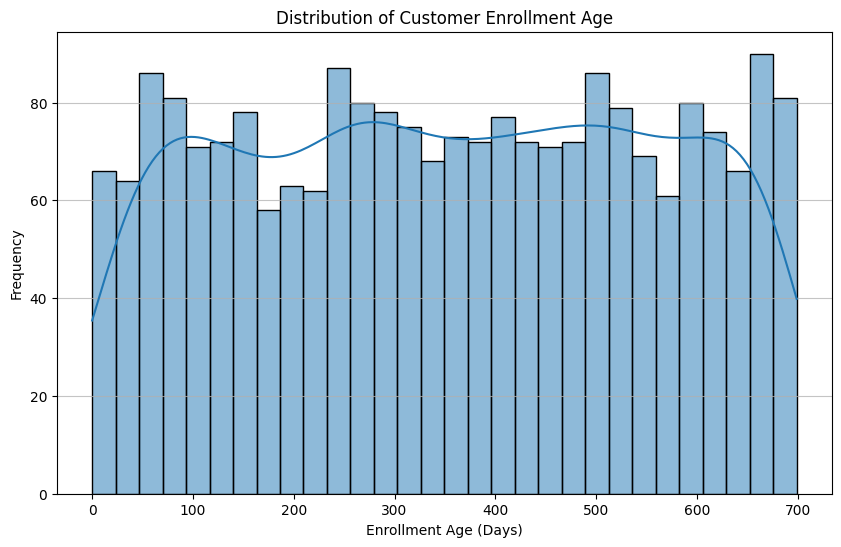

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['EnrollmentAge'], kde=True, bins=30)
plt.title('Distribution of Customer Enrollment Age')
plt.xlabel('Enrollment Age (Days)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Visualize FamilySize Distribution

### Subtask:
Create a bar chart or histogram to visualize the distribution of `FamilySize` to see the typical family structures of the customer base.


**Reasoning**:
The subtask is to visualize the distribution of `FamilySize`. Since `FamilySize` is a discrete variable representing counts, a bar chart showing the frequency of each family size is appropriate. I will use `seaborn.countplot` for this.



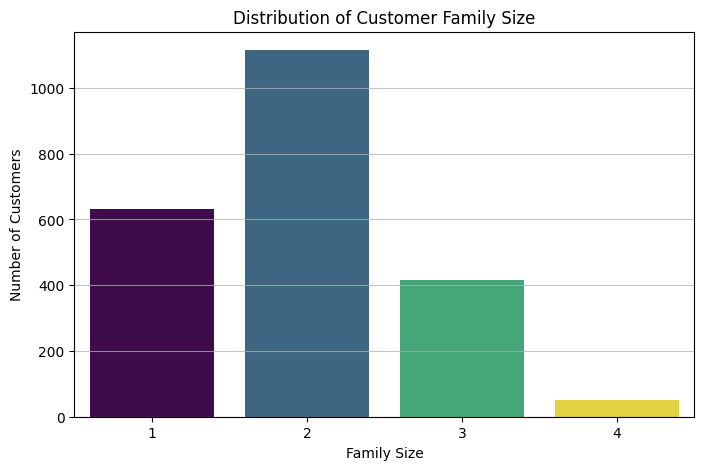

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='FamilySize', data=df, hue='FamilySize', palette='viridis', legend=False)
plt.title('Distribution of Customer Family Size')
plt.xlabel('Family Size')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Visualize Is_Parent Distribution

### Subtask:
Generate a bar chart to show the proportion of customers who are parents (`Is_Parent = 1`) versus those who are not (`Is_Parent = 0`).


**Reasoning**:
Generate a bar chart to show the proportion of customers who are parents versus those who are not, using `seaborn.countplot` as specified in the instructions.



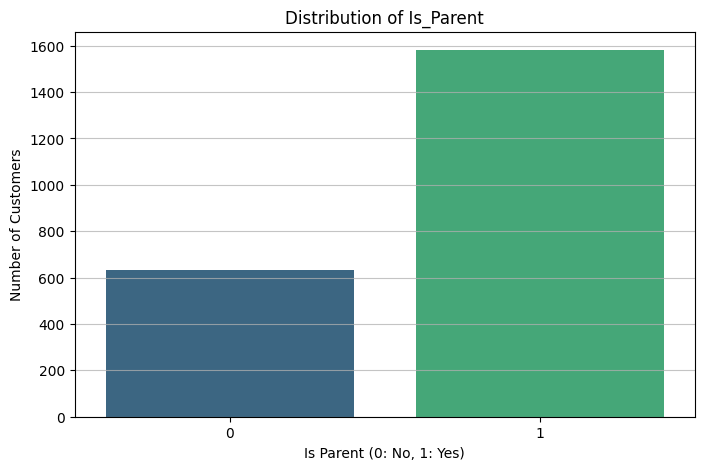

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='Is_Parent', data=df, hue='Is_Parent', palette='viridis', legend=False)
plt.title('Distribution of Is_Parent')
plt.xlabel('Is Parent (0: No, 1: Yes)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Product Spending Analysis

### Subtask:
Analyze and visualize the average spending across different product categories to identify potential 'weak spots' that might indicate customer dissatisfaction or lower engagement.

In [ ]:
product_spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

average_product_spending = df[product_spending_cols].mean().sort_values(ascending=False)

print("Average spending per product category:")
print(average_product_spending)

Average spending per product category:
MntWines            305.226492
MntMeatProducts     167.034810
MntGoldProds         43.928571
MntFishProducts      37.652351
MntSweetProducts     27.047016
MntFruits            26.335895
dtype: float64


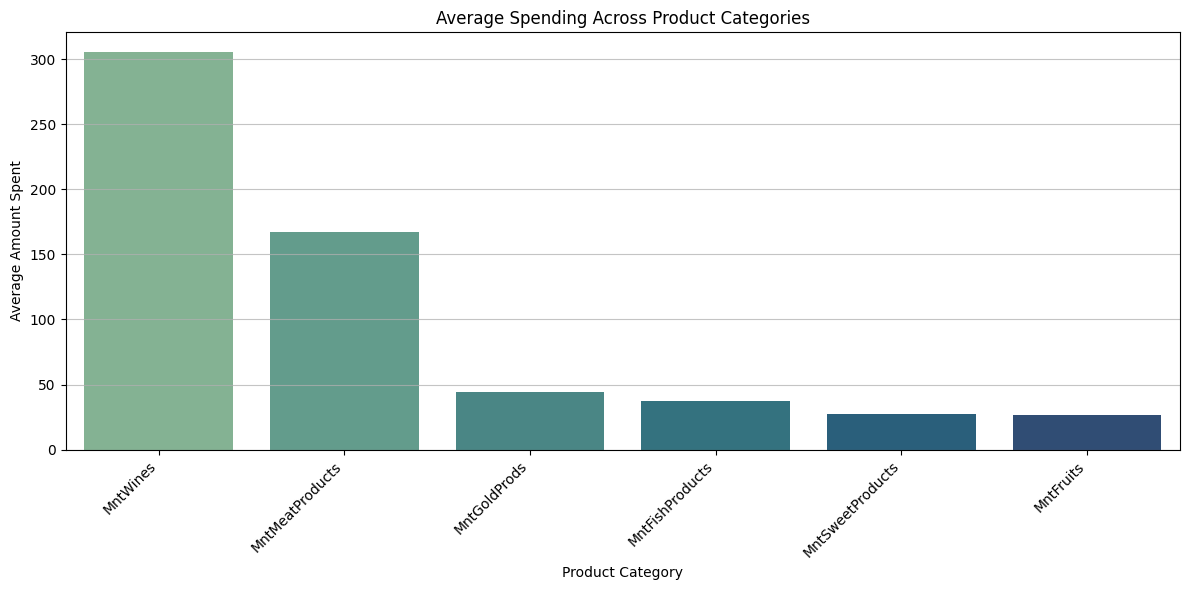

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=average_product_spending.index, y=average_product_spending.values, hue=average_product_spending.index, palette='crest', legend=False)
plt.title('Average Spending Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Average Amount Spent')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Deep Dive: Identifying Engagement Gaps and Potential Dissatisfaction

To find true weak spots, we will look at:
1. **Zero-Spend Analysis**: What percentage of customers buy absolutely nothing from these categories?
2. **Complaint Analysis**: Do customers who filed a complaint (`Complain = 1`) spend significantly less in certain areas?

In [ ]:
zero_spend_rates = (df[product_spending_cols] == 0).mean() * 100
zero_spend_rates = zero_spend_rates.sort_values(ascending=False)

print("Percentage of customers with ZERO spending per category:")
print(zero_spend_rates)

Percentage of customers with ZERO spending per category:
MntSweetProducts    18.580470
MntFruits           17.766727
MntFishProducts     17.088608
MntGoldProds         2.757685
MntWines             0.587703
MntMeatProducts      0.045208
dtype: float64


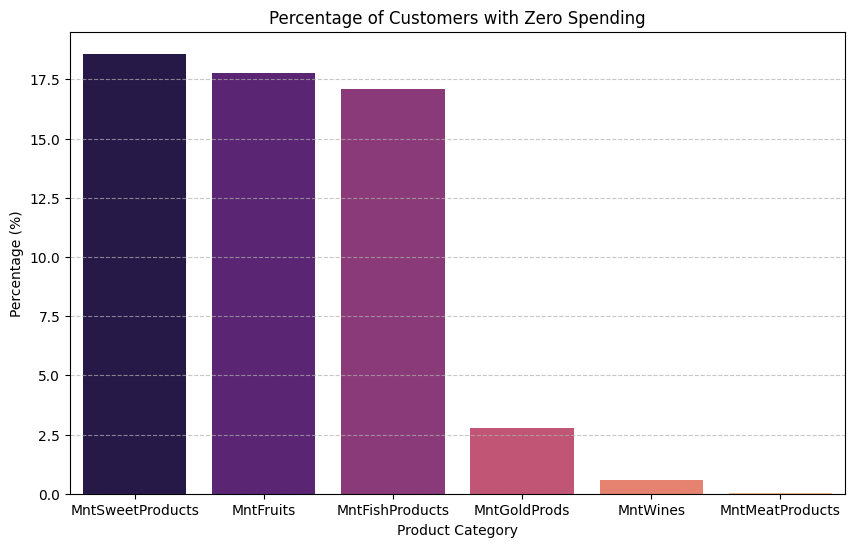

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=zero_spend_rates.index, y=zero_spend_rates.values, hue=zero_spend_rates.index, palette='magma', legend=False)
plt.title('Percentage of Customers with Zero Spending')
plt.ylabel('Percentage (%)')
plt.xlabel('Product Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
complaint_spending = df.groupby('Complain')[product_spending_cols].mean()
print("Average spending: Non-Complainers (0) vs Complainers (1)")
print(complaint_spending)

Average spending: Non-Complainers (0) vs Complainers (1)
            MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Complain                                                            
0         306.399179  26.347172       167.484945        37.752281   
1         176.700000  25.100000       117.700000        26.700000   

          MntSweetProducts  MntGoldProds  
Complain                                  
0                27.127737     44.077555  
1                18.200000     27.600000  


## Identifying Demographics with High Complaints

### Subtask:
Analyze the distribution of complaints across demographics (Education and Marital Status) to find groups with higher rates of dissatisfaction.

In [ ]:
# Calculate complaint rates by Education
edu_complaints = df.groupby('Education')['Complain'].mean().sort_values(ascending=False) * 100

# Calculate complaint rates by Marital Status
marital_complaints = df.groupby('Marital_Status')['Complain'].mean().sort_values(ascending=False) * 100

print("Complaint Rate (%) by Education Level:")
print(edu_complaints)
print("\nComplaint Rate (%) by Marital Status:")
print(marital_complaints)

Complaint Rate (%) by Education Level:
Education
2n Cycle      1.515152
Graduation    1.254480
Master        0.547945
PhD           0.208768
Basic         0.000000
Name: Complain, dtype: float64

Complaint Rate (%) by Marital Status:
Marital_Status
Single      1.279318
Married     0.933489
Together    0.874126
Divorced    0.432900
Absurd      0.000000
Alone       0.000000
Widow       0.000000
YOLO        0.000000
Name: Complain, dtype: float64


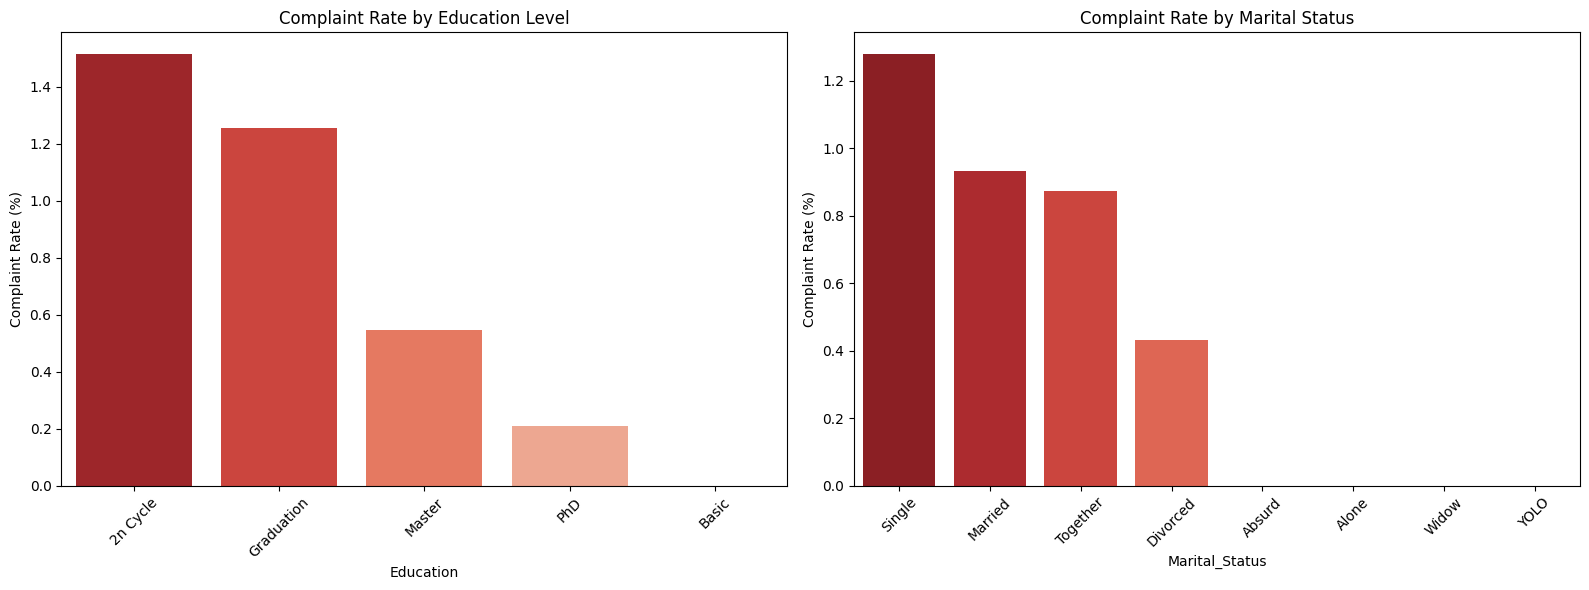

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], x=edu_complaints.index, y=edu_complaints.values, hue=edu_complaints.index, palette='Reds_r', legend=False)
axes[0].set_title('Complaint Rate by Education Level')
axes[0].set_ylabel('Complaint Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x=marital_complaints.index, y=marital_complaints.values, hue=marital_complaints.index, palette='Reds_r', legend=False)
axes[1].set_title('Complaint Rate by Marital Status')
axes[1].set_ylabel('Complaint Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Deep Dive: Impact of Engineered Features on Spending

### Subtask:
Analyze how parenthood (`Is_Parent`), `FamilySize`, and tenure (`EnrollmentAge`) correlate with spending across key product categories.

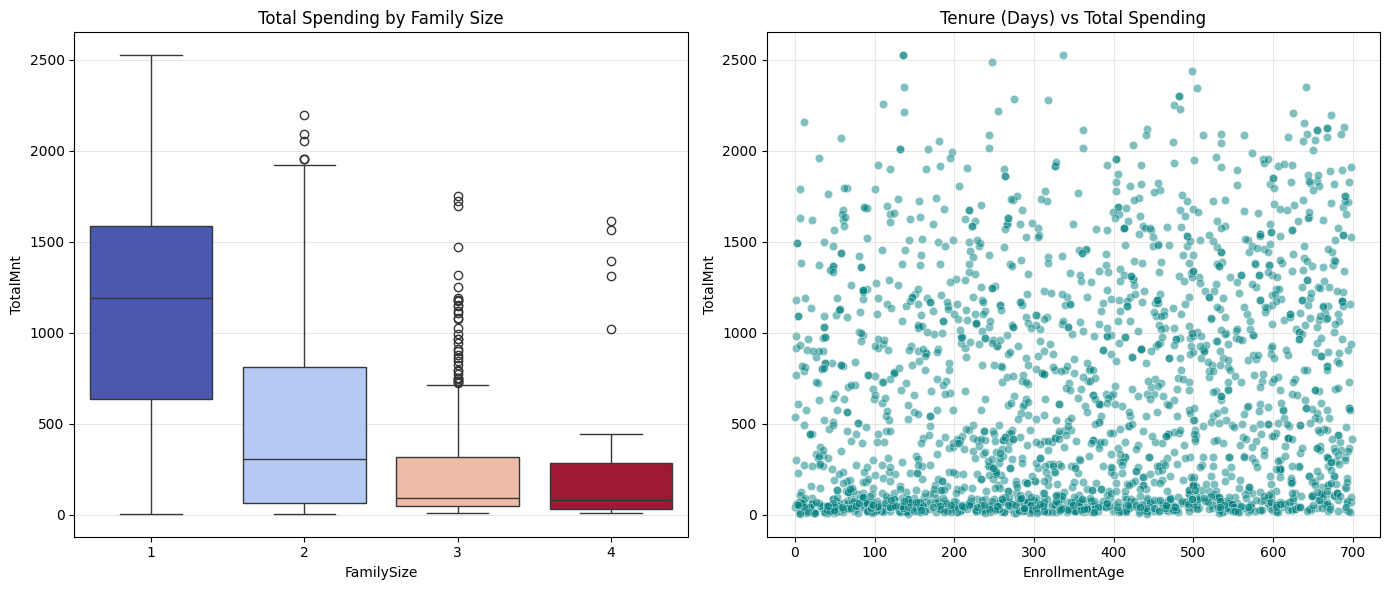

Average Spending per Product: Parents (1) vs Non-Parents (0)


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Is_Parent,,,,,,
0,488.194929,52.212361,371.139461,76.697306,53.247227,64.074485
1,232.201139,16.008223,85.573688,22.068944,16.590133,35.888046


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Spending comparison: Parents vs Non-Parents
parent_spending = df.groupby('Is_Parent')[product_spending_cols].mean()

# 2. Family Size vs Total Spending
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='FamilySize', y='TotalMnt', data=df, hue='FamilySize', palette='coolwarm', legend=False)
plt.title('Total Spending by Family Size')
plt.grid(axis='y', alpha=0.3)

# 3. Tenure (EnrollmentAge) vs Total Spending
plt.subplot(1, 2, 2)
sns.scatterplot(x='EnrollmentAge', y='TotalMnt', data=df, alpha=0.5, color='teal')
plt.title('Tenure (Days) vs Total Spending')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Average Spending per Product: Parents (1) vs Non-Parents (0)")
display(parent_spending)

## Complaints vs. Purchasing Channels

### Subtask:
Analyze if customers who filed complaints show different purchasing patterns across channels (Web, Catalog, Store, and Deals).

In [ ]:
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
complaint_channels = df.groupby('Complain')[channel_cols].mean()

print("Average Purchases by Channel: Non-Complainers (0) vs Complainers (1)")
display(complaint_channels)

Average Purchases by Channel: Non-Complainers (0) vs Complainers (1)


,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases
Complain,,,,
0,4.091697,2.677464,5.809763,2.325274
1,3.700000,2.100000,5.400000,2.400000


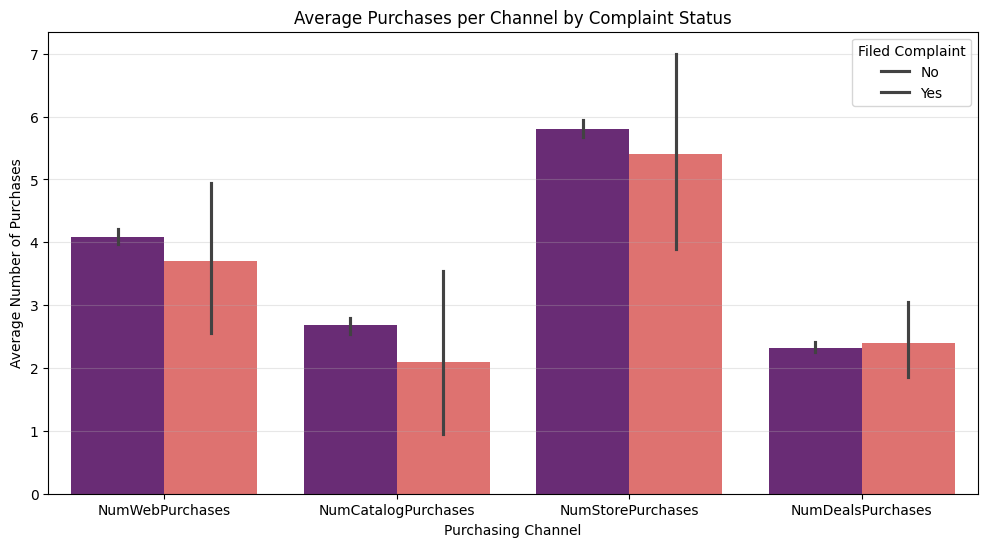

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshaping data for visualization
channel_plot_data = df.melt(id_vars='Complain', value_vars=channel_cols, var_name='Channel', value_name='Purchases')

plt.figure(figsize=(12, 6))
sns.barplot(x='Channel', y='Purchases', hue='Complain', data=channel_plot_data, palette='magma')
plt.title('Average Purchases per Channel by Complaint Status')
plt.ylabel('Average Number of Purchases')
plt.xlabel('Purchasing Channel')
plt.legend(title='Filed Complaint', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.3)
plt.show()

## Spending Profiles of Complainers by Demographic

### Subtask:
Visualize average product spending for customers who filed a complaint, segmented by Education and Marital Status.

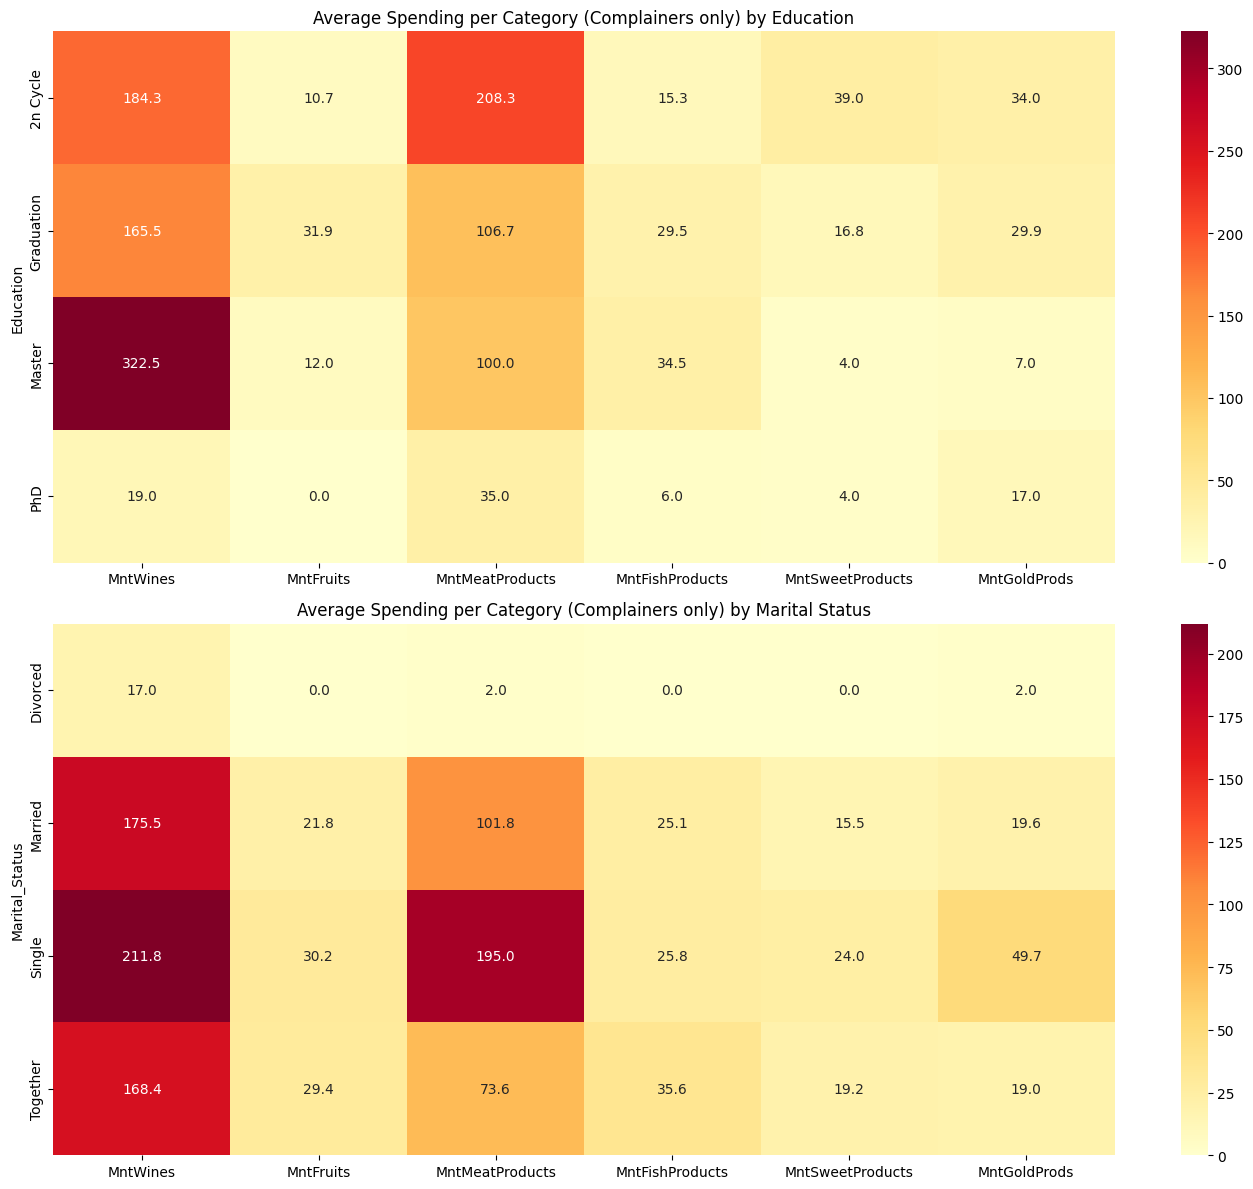

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for customers who filed a complaint
complainers = df[df['Complain'] == 1]

# Group spending by Education and Marital Status for complainers
edu_spending_comp = complainers.groupby('Education')[product_spending_cols].mean()
marital_spending_comp = complainers.groupby('Marital_Status')[product_spending_cols].mean()

# Plotting the Heatmaps
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.heatmap(edu_spending_comp, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title('Average Spending per Category (Complainers only) by Education')

sns.heatmap(marital_spending_comp, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title('Average Spending per Category (Complainers only) by Marital Status')

plt.tight_layout()
plt.show()

## Campaign Engagement vs. Dissatisfaction

### Subtask:
Compare complaint rates and average product spending between customers who accepted at least one offer (`AcceptedCmpOverall > 0`) and those who accepted none.

In [ ]:
# Create a binary engagement flag
df['Has_Accepted_Offer'] = (df['AcceptedCmpOverall'] > 0).astype(int)

# Calculate complaint rates
campaign_complaints = df.groupby('Has_Accepted_Offer')['Complain'].mean() * 100

# Calculate average spending
campaign_spending = df.groupby('Has_Accepted_Offer')[product_spending_cols].mean()

print("Complaint Rate (%) - No Offers Accepted (0) vs. At Least One Accepted (1):")
print(campaign_complaints)
print("\nAverage Product Spending by Campaign Engagement:")
display(campaign_spending)

Complaint Rate (%) - No Offers Accepted (0) vs. At Least One Accepted (1):
Has_Accepted_Offer
0    1.057214
1    0.496689
Name: Complain, dtype: float64

Average Product Spending by Campaign Engagement:


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Has_Accepted_Offer,,,,,,
0,218.100746,22.919776,126.810945,32.295398,22.919154,37.855100
1,537.177152,35.430464,274.120861,51.913907,38.036424,60.097682


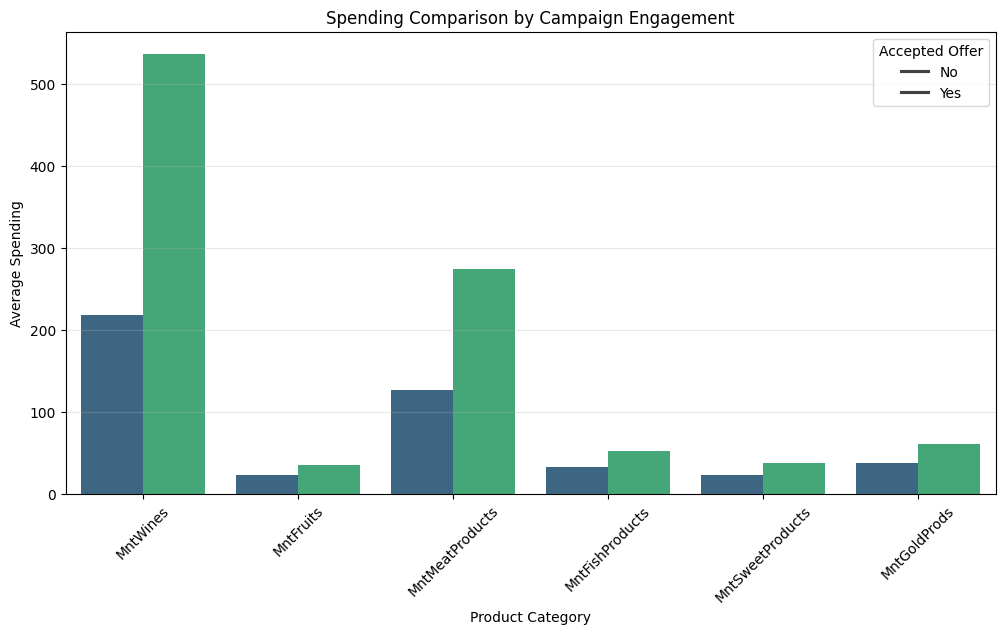

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the spending difference
campaign_spending_melted = campaign_spending.reset_index().melt(id_vars='Has_Accepted_Offer', var_name='Product', value_name='Avg_Spend')

plt.figure(figsize=(12, 6))
sns.barplot(x='Product', y='Avg_Spend', hue='Has_Accepted_Offer', data=campaign_spending_melted, palette='viridis')
plt.title('Spending Comparison by Campaign Engagement')
plt.ylabel('Average Spending')
plt.xlabel('Product Category')
plt.xticks(rotation=45)
plt.legend(title='Accepted Offer', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.3)
plt.show()

### Statistical Comparison: Complaints vs. Campaign Offers
We will compare the count of complaints between those who accepted at least one offer and those who accepted none.

Contingency Table: Accepted Offer (Rows) vs. Complain (Columns)


Complain,0,1
Has_Accepted_Offer,,
0,1591,17
1,601,3


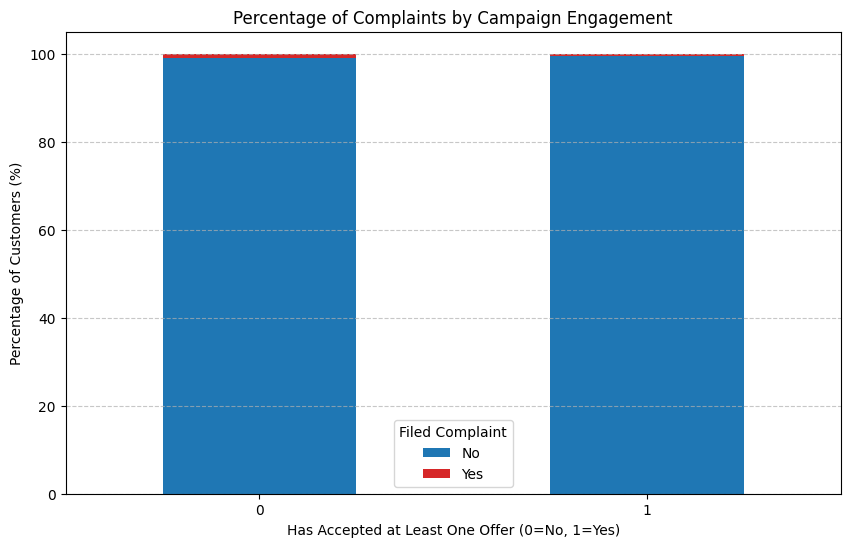

Complaint rate for those who accepted NO offers: 1.06%
Complaint rate for those who accepted at least ONE offer: 0.50%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation of Offer Acceptance vs Complaints
engagement_complaint_ct = pd.crosstab(df['Has_Accepted_Offer'], df['Complain'])

print("Contingency Table: Accepted Offer (Rows) vs. Complain (Columns)")
display(engagement_complaint_ct)

# Calculate percentages for better comparison
engagement_complaint_pct = pd.crosstab(df['Has_Accepted_Offer'], df['Complain'], normalize='index') * 100

# Visualization
engagement_complaint_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#d62728'])
plt.title('Percentage of Complaints by Campaign Engagement')
plt.xlabel('Has Accepted at Least One Offer (0=No, 1=Yes)')
plt.ylabel('Percentage of Customers (%)')
plt.legend(title='Filed Complaint', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Summary stats
print(f"Complaint rate for those who accepted NO offers: {engagement_complaint_pct.iloc[0, 1]:.2f}%")
print(f"Complaint rate for those who accepted at least ONE offer: {engagement_complaint_pct.iloc[1, 1]:.2f}%")